In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

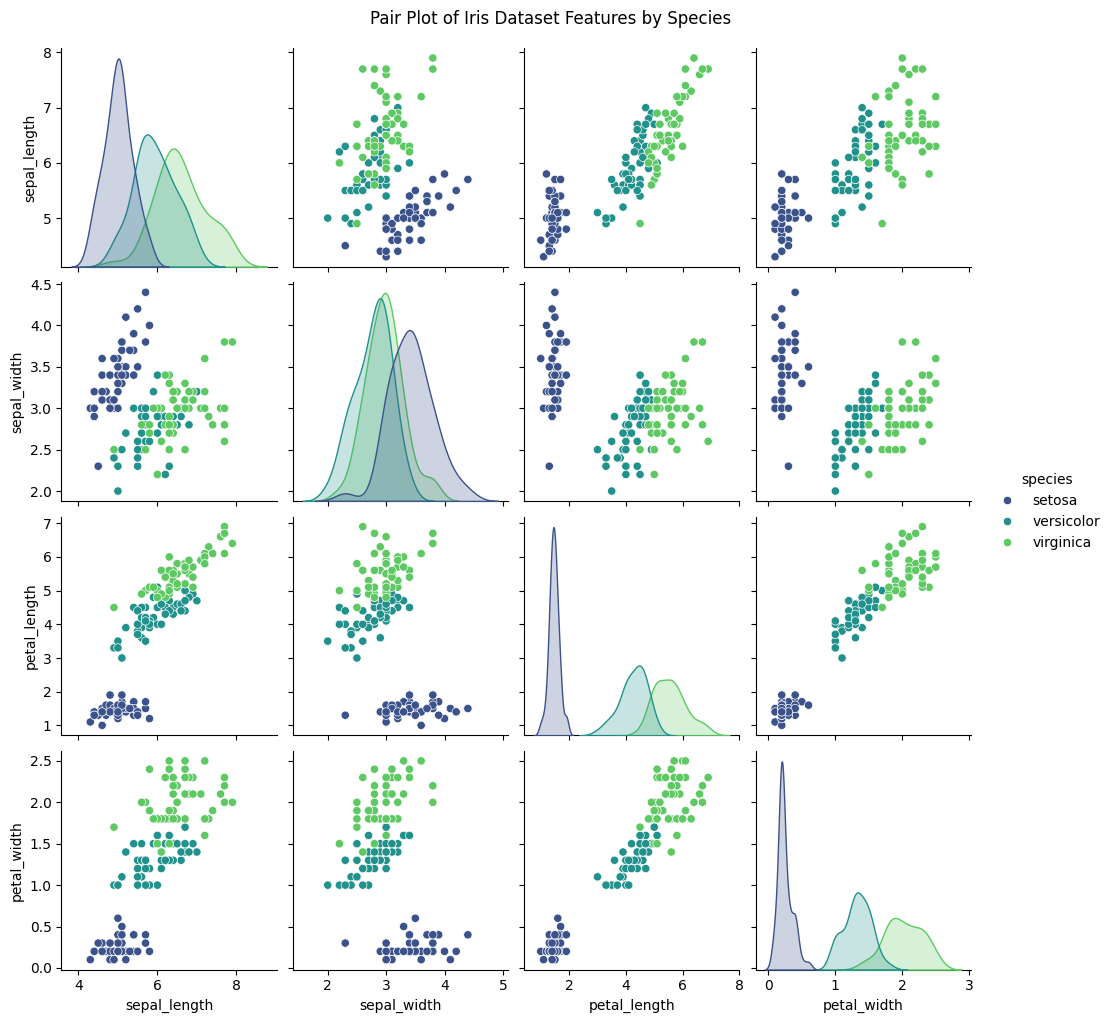

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Pair Plot of Iris Dataset Features by Species', y=1.02)
plt.show()

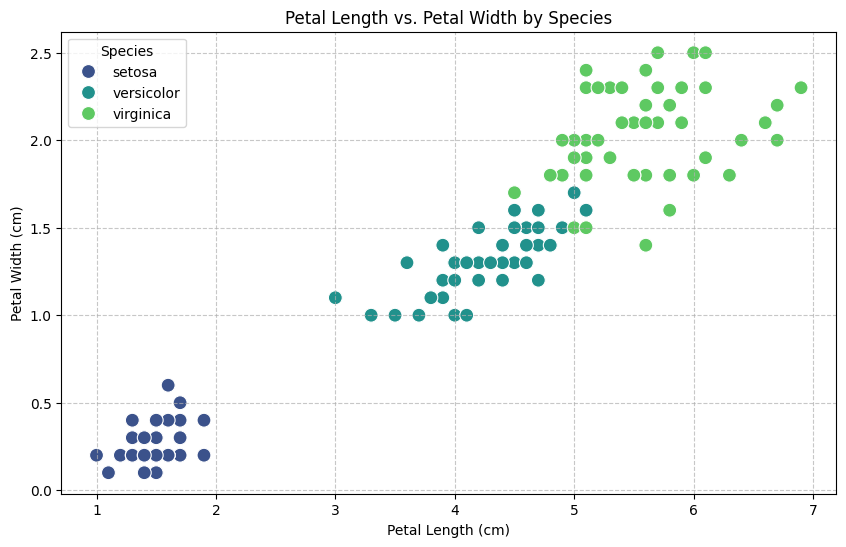

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df, palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **1. Provide summary statistics with numeric variables grouped by one of the qualitative (categorical) variable.**

Reading the dataset


In [70]:
nba_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment_3/nba.csv')
nba_df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [105]:
nba_df.describe()

,Number,Age,Weight,Salary
count,373.000000,373.000000,373.000000,3.730000e+02
mean,16.895442,26.648794,219.627346,4.625677e+06
std,14.974972,4.250551,25.135718,5.057520e+06
min,0.000000,19.000000,161.000000,5.572200e+04
25%,5.000000,24.000000,200.000000,1.007026e+06
50%,12.000000,26.000000,220.000000,2.637720e+06
75%,25.000000,29.000000,240.000000,5.758680e+06
max,99.000000,40.000000,279.000000,2.287500e+07


Basic information

In [71]:
nba_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      457 non-null    object 
 2   Number    457 non-null    float64
 3   Position  457 non-null    object 
 4   Age       457 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


Checking for null values

In [72]:
nba_df.isnull().sum()

,0
Name,1
Team,1
Number,1
Position,1
Age,1
Height,1
Weight,1
College,85
Salary,12


Handling null values

In [73]:
nba_df["College"] = nba_df["College"].fillna(nba_df["College"].mode())
nba_df["Salary"] = nba_df["Salary"].fillna(nba_df["Salary"].mean())
nba_df.dropna(inplace=True)


In [74]:
nba_df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,0
Salary,0


Grouping based on 'Height' attribute

In [75]:
height_groups = nba_df.groupby(nba_df["Height"])
height_groups.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7.730337e+06
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6.796117e+06
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4.842684e+06
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1.148640e+06
6,Jordan Mickey,Boston Celtics,55.0,PF,21.0,6-8,235.0,LSU,1.170960e+06
...,...,...,...,...,...,...,...,...,...
203,Ty Lawson,Indiana Pacers,10.0,PG,28.0,5-11,195.0,North Carolina,2.117440e+05
230,Raymond Felton,Dallas Mavericks,2.0,PG,31.0,6-1,205.0,North Carolina,3.950313e+06
244,Patrick Beverley,Houston Rockets,2.0,PG,27.0,6-1,185.0,Arkansas,6.486486e+06
329,Spencer Hawes,Charlotte Hornets,0.0,PF,28.0,7-1,245.0,Washington,6.110034e+06


In [76]:
pos_groups = nba_df.groupby(nba_df["Position"])
pos_groups.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7.730337e+06
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6.796117e+06
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4.842684e+06
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1.148640e+06
6,Jordan Mickey,Boston Celtics,55.0,PF,21.0,6-8,235.0,LSU,1.170960e+06
7,Kelly Olynyk,Boston Celtics,41.0,C,25.0,7-0,238.0,Gonzaga,2.165160e+06
8,Terry Rozier,Boston Celtics,12.0,PG,22.0,6-2,190.0,Louisville,1.824360e+06
9,Marcus Smart,Boston Celtics,36.0,PG,22.0,6-4,220.0,Oklahoma State,3.431040e+06
10,Jared Sullinger,Boston Celtics,7.0,C,24.0,6-9,260.0,Ohio State,2.569260e+06
11,Isaiah Thomas,Boston Celtics,4.0,PG,27.0,5-9,185.0,Washington,6.912869e+06


/tmp/ipython-input-1709131781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='sepal_length', data=df, palette='viridis')


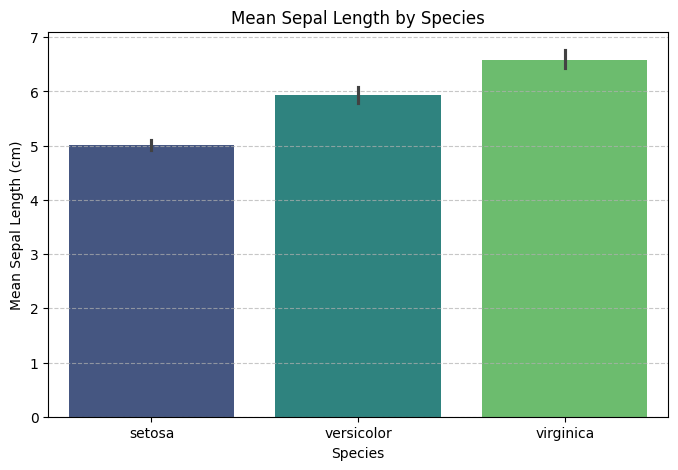

In [77]:
plt.figure(figsize=(8, 5))
sns.barplot(x='species', y='sepal_length', data=df, palette='viridis')
plt.title('Mean Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Mean Sepal Length (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-1230038389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='sepal_width', data=df, palette='viridis')


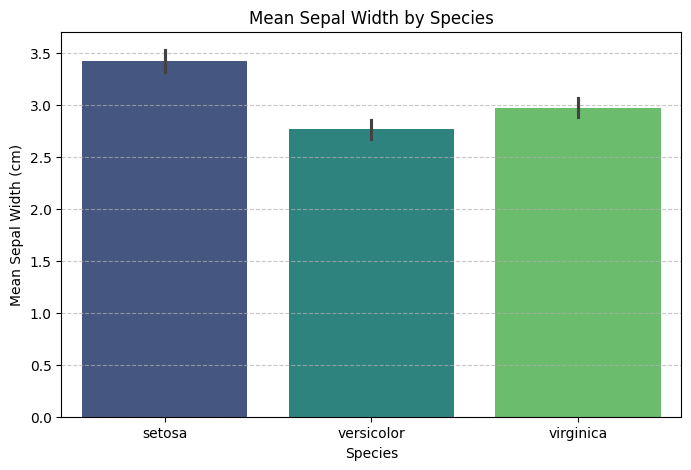

In [78]:
plt.figure(figsize=(8, 5))
sns.barplot(x='species', y='sepal_width', data=df, palette='viridis')
plt.title('Mean Sepal Width by Species')
plt.xlabel('Species')
plt.ylabel('Mean Sepal Width (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-4040529023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='petal_length', data=df, palette='viridis')


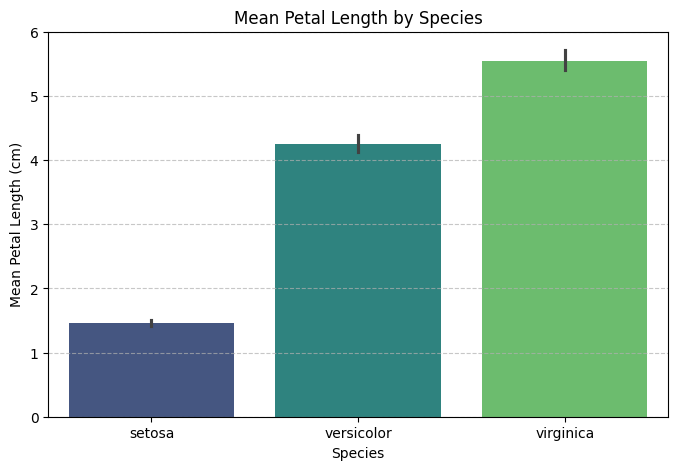

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(x='species', y='petal_length', data=df, palette='viridis')
plt.title('Mean Petal Length by Species')
plt.xlabel('Species')
plt.ylabel('Mean Petal Length (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-3012575781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='petal_width', data=df, palette='viridis')


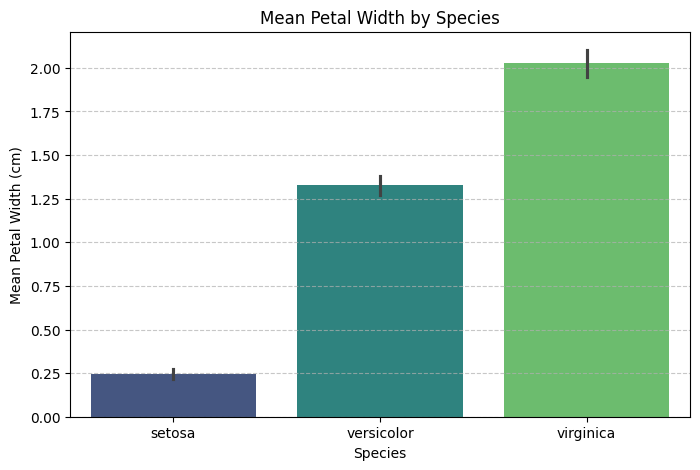

In [80]:
plt.figure(figsize=(8, 5))
sns.barplot(x='species', y='petal_width', data=df, palette='viridis')
plt.title('Mean Petal Width by Species')
plt.xlabel('Species')
plt.ylabel('Mean Petal Width (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [81]:
pos_groups["Salary"].describe()

,count,mean,std,min,25%,50%,75%,max
Position,,,,,,,,
C,49.0,5.763867e+06,5.786112e+06,83397.0,1276000.00,3398280.0,7700000.00,19689000.0
PF,84.0,4.473656e+06,4.892837e+06,111444.0,1064376.75,2899080.5,5230330.00,22192730.0
PG,80.0,4.912400e+06,4.914530e+06,55722.0,1448610.00,3018463.5,6678217.25,21468695.0
SF,71.0,4.595908e+06,5.446876e+06,200600.0,990674.00,2000000.0,5915702.00,22875000.0
SG,89.0,3.908533e+06,4.545877e+06,55722.0,947276.00,1584480.0,5675000.00,20000000.0


In [82]:
height_groups["Salary"].describe()

,count,mean,std,min,25%,50%,75%,max
Height,,,,,,,,
5-11,3.0,5.891553e+05,7.926627e+05,55722.0,133733.00,211744.0,8.558720e+05,1500000.0
5-9,1.0,6.912869e+06,NaN,6912869.0,6912869.00,6912869.0,6.912869e+06,6912869.0
6-0,10.0,5.784075e+06,6.337144e+06,947276.0,2437500.00,3934473.5,4.846419e+06,21468695.0
6-1,12.0,5.456567e+06,4.585905e+06,700902.0,1898610.00,3402626.5,9.522106e+06,13500000.0
6-10,34.0,5.111545e+06,5.162012e+06,222888.0,1044792.25,3782500.0,6.860602e+06,19689000.0
6-11,29.0,5.920326e+06,7.067208e+06,245177.0,1140240.00,2109294.0,8.193029e+06,22192730.0
6-2,15.0,2.862862e+06,2.576949e+06,525093.0,947276.00,1282080.0,4.842684e+06,8000000.0
6-3,27.0,5.765194e+06,5.759044e+06,189455.0,1841940.00,4053446.0,7.500000e+06,20093064.0
6-4,28.0,4.358526e+06,5.135309e+06,134215.0,1006902.75,2515440.0,5.167034e+06,20000000.0


In [83]:
pos_height_groups = nba_df.groupby(["Position", "Height"])
pos_height_groups.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7.730337e+06
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6.796117e+06
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4.842684e+06
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1.148640e+06
6,Jordan Mickey,Boston Celtics,55.0,PF,21.0,6-8,235.0,LSU,1.170960e+06
...,...,...,...,...,...,...,...,...,...
381,Marcus Thornton,Washington Wizards,15.0,SF,29.0,6-4,205.0,LSU,2.006000e+05
392,Mike Miller,Denver Nuggets,3.0,SG,36.0,6-8,218.0,Florida,9.472760e+05
396,JaKarr Sampson,Denver Nuggets,9.0,SG,23.0,6-9,214.0,St. John's,2.584890e+05
411,Andrew Wiggins,Minnesota Timberwolves,22.0,SG,21.0,6-8,199.0,Kansas,5.758680e+06


In [84]:
pos_height_groups["Salary"].describe()

count          mean           std         min          25%  \
Position Height                                                               
C        6-10      8.0  4.426655e+06  3.975244e+06    222888.0    947276.00   
         6-11     14.0  7.446095e+06  7.100726e+06   1100602.0   1608017.00   
         6-8       1.0  8.339700e+04           NaN     83397.0     83397.00   
         6-9       5.0  4.089645e+06  5.774647e+06    273038.0    845059.00   
         7-0      19.0  5.412629e+06  5.294404e+06    947276.0   1718062.00   
         7-1       1.0  3.807120e+06           NaN   3807120.0   3807120.00   
         7-2       1.0  1.559222e+07           NaN  15592217.0  15592217.00   
PF       6-10     23.0  5.322431e+06  5.276840e+06    845059.0   1346940.00   
         6-11     15.0  4.496275e+06  6.969308e+06    245177.0    896167.50   
         6-7       1.0  1.426087e+07           NaN  14260870.0  14260870.00   
         6-8      15.0  4.916841e+06  5.019755e+06    525093.0   2010480.00   
         6-9      27.0  3.126949e+06  2.577312e+06    111444.0   1003513.00   
         7-0       1.0  4.300000e+06           NaN   4300000.0   4300000.00   
         7-1       2.0  4.592957e+06  2.145471e+06   3075880.0   3834418.50   
PG       5-11      3.0  5.891553e+05  7.926627e+05     55722.0    133733.00   
         5-9       1.0  6.912869e+06           NaN   6912869.0   6912869.00   
         6-0      10.0  5.784075e+06  6.337144e+06    947276.0   2437500.00   
         6-1      12.0  5.456567e+06  4.585905e+06    700902.0   1898610.00   
         6-2      12.0  3.350277e+06  2.674934e+06    525093.0   1125400.00   
         6-3      25.0  6.154716e+06  5.813483e+06    189455.0   2139000.00   
         6-4       8.0  5.044928e+06  5.292246e+06   1147276.0   2001669.00   
         6-5       6.0  2.786224e+06  2.686400e+06    111444.0   1011134.25   
         6-6       3.0  3.281366e+06  2.977199e+06    845059.0   1622049.50   
SF       6-10      3.0  5.321118e+06  8.695228e+06    295327.0    300927.00   
         6-4       1.0  2.006000e+05           NaN    200600.0    200600.00   
         6-5       2.0  5.500000e+06  4.949747e+06   2000000.0   3750000.00   
         6-6      12.0  3.028394e+06  3.402504e+06    525093.0    947275.75   
         6-7      24.0  2.756571e+06  3.321219e+06    206192.0    972830.00   
         6-8      14.0  7.408213e+06  6.670415e+06    845059.0   2125920.00   
         6-9      15.0  6.195472e+06  6.862339e+06    845059.0   1100602.00   
SG       6-2       3.0  9.132037e+05  5.901501e+04    845059.0    896167.50   
         6-3       2.0  8.961675e+05  7.227833e+04    845059.0    870613.25   
         6-4      19.0  4.288352e+06  5.243099e+06    134215.0    964312.00   
         6-5      22.0  4.711680e+06  4.575005e+06     55722.0   1159800.00   
         6-6      22.0  2.885245e+06  3.203676e+06    167406.0    947276.00   
         6-7      12.0  4.756633e+06  5.953311e+06    200600.0    901994.75   
         6-8       6.0  4.108158e+06  5.522697e+06    947276.0    947276.00   
         6-9       3.0  4.329288e+06  3.988184e+06    258489.0   2379244.50   

                        50%           75%         max  
Position Height                                        
C        6-10     3907500.0  6.620200e+06  12000000.0  
         6-11     3927385.5  1.523896e+07  19689000.0  
         6-8        83397.0  8.339700e+04     83397.0  
         6-9      2500000.0  2.569260e+06  14260870.0  
         7-0      3398280.0  6.701800e+06  19689000.0  
         7-1      3807120.0  3.807120e+06   3807120.0  
         7-2     15592217.0  1.559222e+07  15592217.0  
PF       6-10     3750000.0  6.307228e+06  19689000.0  
         6-11     1391160.0  3.200510e+06  22192730.0  
         6-7     14260870.0  1.426087e+07  14260870.0  
         6-8      3000000.0  4.963720e+06  18671659.0  
         6-9      2489530.0  4.507182e+06   9638555.0  
         7-0      4300000.0  4.300000e+06   4300000.0  
         7-1    

In [85]:
nba_df["Age"].max()

40.0

In [86]:
nba_df["Age"].min()

19.0

Creating age groups and dividing the dataset according to groups

In [87]:
bins = [19,25,31,36,40]
labels = ["19-24", "25-30", "31-35", "36-40"]
nba_df["AgeGroup"] = pd.cut(nba_df["Age"], bins=bins, labels=labels)


In [88]:
nba_df["AgeGroup"].value_counts()

,count
AgeGroup,
19-24,171
25-30,151
31-35,41
36-40,8


In [89]:
age_groups = nba_df.groupby("AgeGroup")

/tmp/ipython-input-196454319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = nba_df.groupby("AgeGroup")


In [90]:
age_groups["Salary"].describe()

,count,mean,std,min,25%,50%,75%,max
AgeGroup,,,,,,,,
19-24,171.0,3.099927e+06,3.689180e+06,55722.0,947276.0,1572360.0,3.495566e+06,16407501.0
25-30,151.0,6.433366e+06,5.801305e+06,55722.0,1298000.0,4775000.0,1.002500e+07,21468695.0
31-35,41.0,4.780806e+06,5.458128e+06,200600.0,1449187.0,3300000.0,5.158539e+06,22875000.0
36-40,8.0,2.997202e+06,2.180022e+06,222888.0,773144.5,3732009.5,4.882013e+06,5250000.0


# **2. Python program to display some basic statistical details**

In [91]:
from sklearn.datasets import load_iris

iris = load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [92]:
import pandas as pd
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]
df = df.rename(columns = {
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})

In [106]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [93]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [94]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [95]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [97]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [98]:
df[ df["species"] == "setosa" ]["sepal_length"].describe()

,sepal_length
count,50.00000
mean,5.00600
std,0.35249
min,4.30000
25%,4.80000
50%,5.00000
75%,5.20000
max,5.80000


In [99]:
df[ df["species"] == "versicolor" ]["sepal_length"].describe()


,sepal_length
count,50.000000
mean,5.936000
std,0.516171
min,4.900000
25%,5.600000
50%,5.900000
75%,6.300000
max,7.000000


In [100]:
df[ df["species"] == "virginica" ]["sepal_length"].describe()

,sepal_length
count,50.00000
mean,6.58800
std,0.63588
min,4.90000
25%,6.22500
50%,6.50000
75%,6.90000
max,7.90000


In [101]:
species_sepal_length_stats = df.groupby('species')['sepal_length'].describe()
print(species_sepal_length_stats)

            count   mean       std  min    25%  50%  75%  max
species                                                      
setosa       50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8
versicolor   50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0
virginica    50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9


In [102]:
species_sepal_width_stats = df.groupby('species')['sepal_width'].describe()
print(species_sepal_width_stats)

            count   mean       std  min    25%  50%    75%  max
species                                                        
setosa       50.0  3.428  0.379064  2.3  3.200  3.4  3.675  4.4
versicolor   50.0  2.770  0.313798  2.0  2.525  2.8  3.000  3.4
virginica    50.0  2.974  0.322497  2.2  2.800  3.0  3.175  3.8


In [103]:
species_petal_length_stats = df.groupby('species')['petal_length'].describe()
print(species_petal_length_stats)

            count   mean       std  min  25%   50%    75%  max
species                                                       
setosa       50.0  1.462  0.173664  1.0  1.4  1.50  1.575  1.9
versicolor   50.0  4.260  0.469911  3.0  4.0  4.35  4.600  5.1
virginica    50.0  5.552  0.551895  4.5  5.1  5.55  5.875  6.9


In [104]:
species_petal_width_stats = df.groupby('species')['petal_width'].describe()
print("Summary statistics of 'petal_width' grouped by 'species':")
print(species_petal_width_stats)

Summary statistics of 'petal_width' grouped by 'species':
            count   mean       std  min  25%  50%  75%  max
species                                                    
setosa       50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6
versicolor   50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8
virginica    50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5


**Petal dimensions (length and width)** are the most effective features for distinguishing the species. Iris Setosa is almost perfectly separated from Iris Versicolor and Iris Virginica by these features -> (petal length and petal width)